# Phân Tích Phân Khúc Khách Hàng (Customer Segmentation)

**Dataset:** Mall Customers — 200 khách hàng tại trung tâm mua sắm  
**Mục tiêu:** Phân nhóm khách hàng dựa trên đặc điểm nhân khẩu học và hành vi chi tiêu, từ đó rút ra insight phục vụ chiến lược marketing.

---

## Nội dung
1. [Load & Khám phá dữ liệu (EDA)](#eda)
2. [Feature Engineering & Tiền xử lý](#fe)
3. [Tìm số cụm tối ưu K (Elbow + Silhouette)](#optk)
4. [K-Means Clustering](#kmeans)
5. [Hierarchical (Agglomerative) Clustering](#hier)
6. [So sánh hai phương pháp](#compare)
7. [Phân tích hồ sơ từng cụm (Cluster Profiling)](#profile)
8. [Kết luận & Business Insights](#conclusion)

## 0. Cài đặt thư viện & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
<a id='eda'></a>
## 1. Load & Khám phá dữ liệu (EDA)

Dataset **Mall Customers** gồm 200 bản ghi với các biến:

| Cột | Mô tả |
|-----|-------|
| `CustomerID` | ID định danh (không dùng cho phân tích) |
| `Gender` | Giới tính (Male/Female) |
| `Age` | Tuổi |
| `Annual Income (k$)` | Thu nhập hàng năm (nghìn USD) |
| `Spending Score (1–100)` | Điểm chi tiêu do trung tâm chấm dựa trên hành vi mua sắm |

In [2]:
df_raw = pd.read_csv('data/Mall_Customers.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
print('=== Thông tin tổng quan ===')
df_raw.info()
print()
print('=== Thống kê mô tả ===')
df_raw.describe().round(2)

=== Thông tin tổng quan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== Thống kê mô tả ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [4]:
print('Missing values:')
print(df_raw.isnull().sum())
print(f'\nPhân bố giới tính:\n{df_raw["Gender"].value_counts()}')

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Phân bố giới tính:
Gender
Female    112
Male       88
Name: count, dtype: int64


### 1.1 Phân phối từng biến

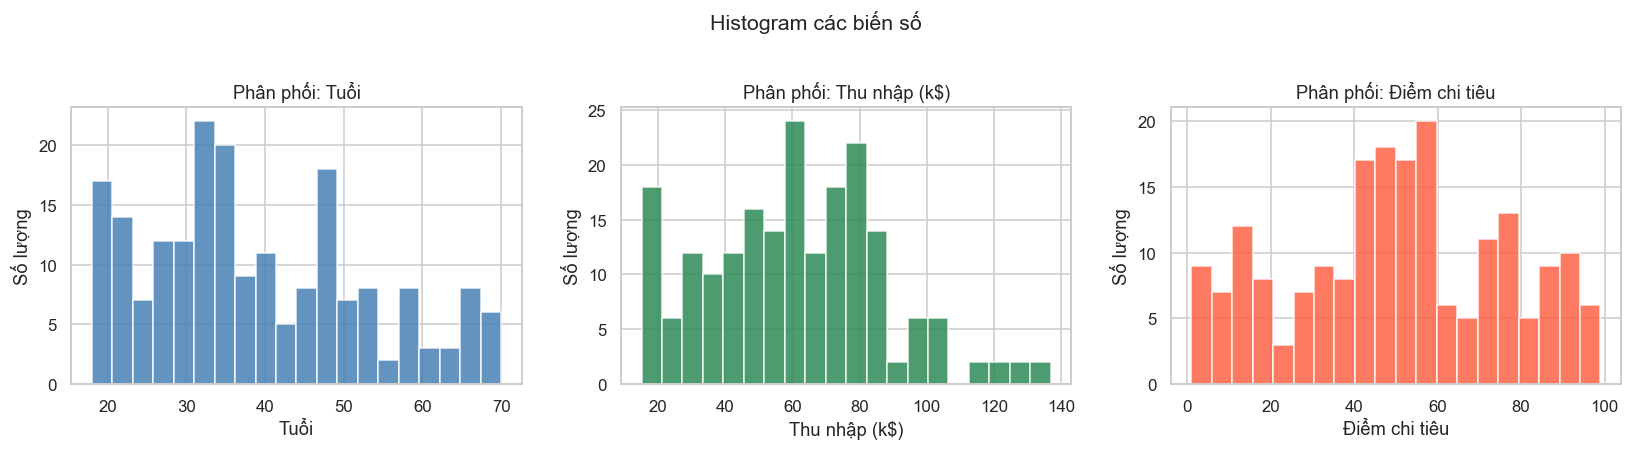

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
labels   = ['Tuổi', 'Thu nhập (k$)', 'Điểm chi tiêu']
colors   = ['steelblue', 'seagreen', 'tomato']

for ax, col, lbl, clr in zip(axes, num_cols, labels, colors):
    ax.hist(df_raw[col], bins=20, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(f'Phân phối: {lbl}', fontsize=12)
    ax.set_xlabel(lbl)
    ax.set_ylabel('Số lượng')

plt.suptitle('Histogram các biến số', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Boxplot theo giới tính

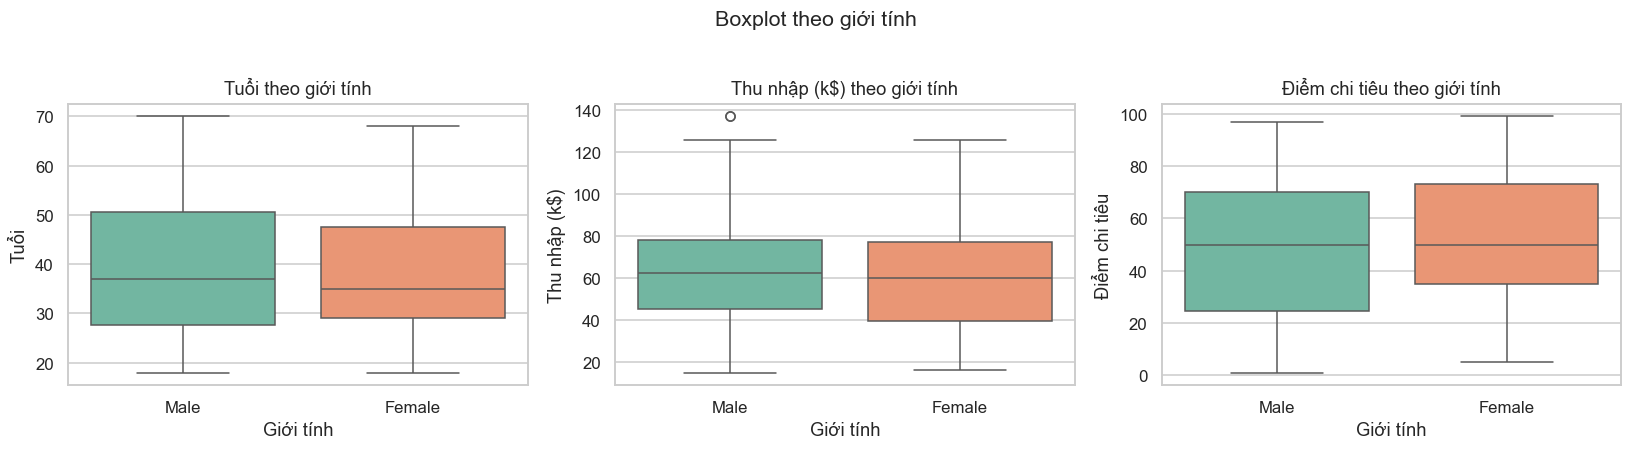

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, lbl in zip(axes, num_cols, labels):
    sns.boxplot(data=df_raw, x='Gender', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{lbl} theo giới tính')
    ax.set_xlabel('Giới tính')
    ax.set_ylabel(lbl)

plt.suptitle('Boxplot theo giới tính', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Ma trận tương quan & Scatter plot

Tương quan giữa **Thu nhập** và **Điểm chi tiêu** là trọng tâm phân tích — hai biến này quyết định phần lớn cấu trúc cụm.

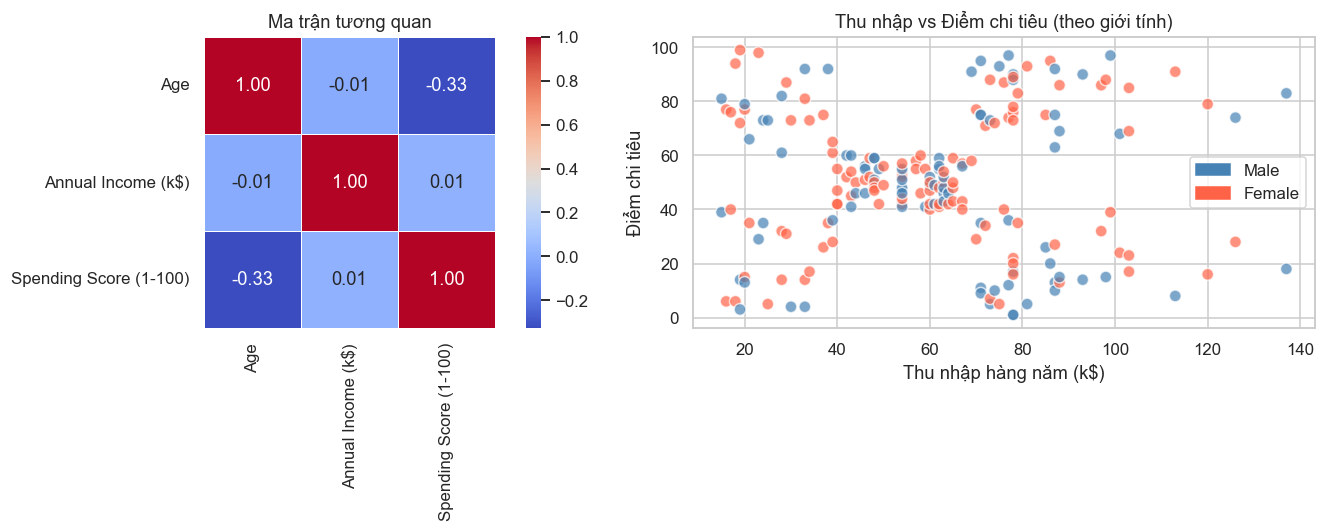

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap tương quan
corr = df_raw[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            square=True, linewidths=0.5)
axes[0].set_title('Ma trận tương quan')

# Scatter: Income vs Spending Score
scatter_colors = df_raw['Gender'].map({'Male': 'steelblue', 'Female': 'tomato'})
axes[1].scatter(df_raw['Annual Income (k$)'], df_raw['Spending Score (1-100)'],
                c=scatter_colors, alpha=0.7, edgecolor='white', s=60)
axes[1].set_xlabel('Thu nhập hàng năm (k$)')
axes[1].set_ylabel('Điểm chi tiêu')
axes[1].set_title('Thu nhập vs Điểm chi tiêu (theo giới tính)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='steelblue', label='Male'),
                         Patch(color='tomato', label='Female')])

plt.tight_layout()
plt.show()

> **Nhận xét EDA:**
> - Không có missing values — dataset sạch.
> - Biểu đồ scatter cho thấy khả năng tồn tại **5 nhóm tự nhiên** trên không gian Income × Spending Score.
> - Phân bố tuổi có đuôi phải (nhiều khách trẻ).
> - Hai giới tính có hành vi chi tiêu tương đồng nhau.

---
<a id='fe'></a>
## 2. Feature Engineering & Tiền xử lý

**Các bước thực hiện:**
1. Đổi tên cột cho tiện thao tác.
2. Tạo feature `spending_score_per_income` = điểm chi tiêu / thu nhập — nắm bắt **tỷ lệ chi tiêu tương đối**.
3. Chuẩn hóa (StandardScaler) để các thuật toán clustering không bị ảnh hưởng bởi đơn vị.

In [8]:
df = df_raw.copy()

# Đổi tên
df = df.rename(columns={
    'Annual Income (k$)': 'income',
    'Spending Score (1-100)': 'spending_score'
})

# Feature ratio
df['spending_score_per_income'] = df['spending_score'] / (df['income'] + 1e-6)

# Feature selection — không dùng CustomerID, Gender
FEATURES = ['Age', 'income', 'spending_score', 'spending_score_per_income']

X = df[FEATURES].copy()

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

print('Features sau tiền xử lý:')
X_scaled_df.describe().round(3)

Features sau tiền xử lý:


,Age,income,spending_score,spending_score_per_income
count,200.000,200.000,200.000,200.000
mean,-0.000,-0.000,-0.000,0.000
std,1.003,1.003,1.003,1.003
min,-1.496,-1.739,-1.910,-1.087
25%,-0.725,-0.728,-0.600,-0.449
50%,-0.205,0.036,-0.008,-0.186
75%,0.728,0.666,0.885,0.064
max,2.236,2.918,1.894,4.461


---
<a id='optk'></a>
## 3. Tìm số cụm tối ưu K

Sử dụng hai phương pháp để xác định K:

| Phương pháp | Ý tưởng | Điểm cần quan sát |
|---|---|---|
| **Elbow Method** | Vẽ WCSS theo K, tìm "khuỷu tay" | Điểm uốn của đường cong |
| **Silhouette Score** | Đo mức độ gắn kết nội cụm và tách biệt liên cụm, giá trị ∈ [-1, 1] | K nào cho silhouette cao nhất |

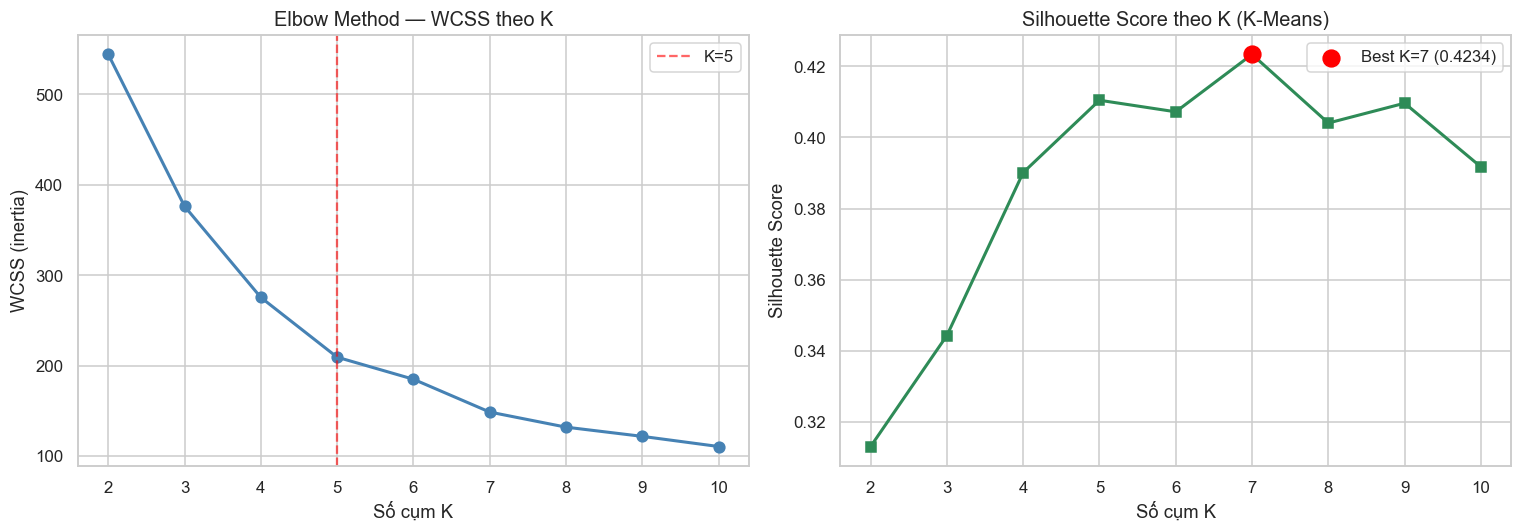


K tốt nhất theo Silhouette (K-Means): K = 7  (score = 0.4234)


In [9]:
K_RANGE = range(2, 11)

wcss_list = []
sil_kmeans = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    lbl = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil_kmeans.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), wcss_list, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — WCSS theo K', fontsize=13)
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('WCSS (inertia)')
axes[0].set_xticks(list(K_RANGE))
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.6, label='K=5')
axes[0].legend()

# Silhouette
best_k_idx = int(np.argmax(sil_kmeans))
best_k     = list(K_RANGE)[best_k_idx]
axes[1].plot(list(K_RANGE), sil_kmeans, 's-', color='seagreen', linewidth=2, markersize=7)
axes[1].scatter([best_k], [sil_kmeans[best_k_idx]], color='red', zorder=5, s=120,
                label=f'Best K={best_k} ({sil_kmeans[best_k_idx]:.4f})')
axes[1].set_title('Silhouette Score theo K (K-Means)', fontsize=13)
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nK tốt nhất theo Silhouette (K-Means): K = {best_k}  (score = {sil_kmeans[best_k_idx]:.4f})')

> **Nhận xét:**  
> - Elbow cho thấy độ dốc giảm đột ngột tại K=5, sau đó phẳng dần — xác nhận K=5 là điểm "khuỷu tay".
> - Silhouette đạt cực đại tại **K=5** → chọn **K = 5** cho cả hai phương pháp.

---
<a id='kmeans'></a>
## 4. K-Means Clustering (K = 5)

In [10]:
K_OPT = 5

kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init='auto')
km_labels = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = km_labels

km_sil = silhouette_score(X_scaled, km_labels)
km_db  = davies_bouldin_score(X_scaled, km_labels)

print(f'K-Means (K={K_OPT})')
print(f'  Silhouette Score  : {km_sil:.4f}  (cao hơn tốt hơn, max=1)')
print(f'  Davies-Bouldin    : {km_db:.4f}  (thấp hơn tốt hơn, min=0)')
print(f'  WCSS (Inertia)    : {kmeans.inertia_:.2f}')
print(f'\nSố mẫu mỗi cụm:')
print(pd.Series(km_labels).value_counts().sort_index())

K-Means (K=5)
  Silhouette Score  : 0.4105  (cao hơn tốt hơn, max=1)
  Davies-Bouldin    : 0.8508  (thấp hơn tốt hơn, min=0)
  WCSS (Inertia)    : 209.27

Số mẫu mỗi cụm:
0    58
1    39
2    23
3    34
4    46
Name: count, dtype: int64


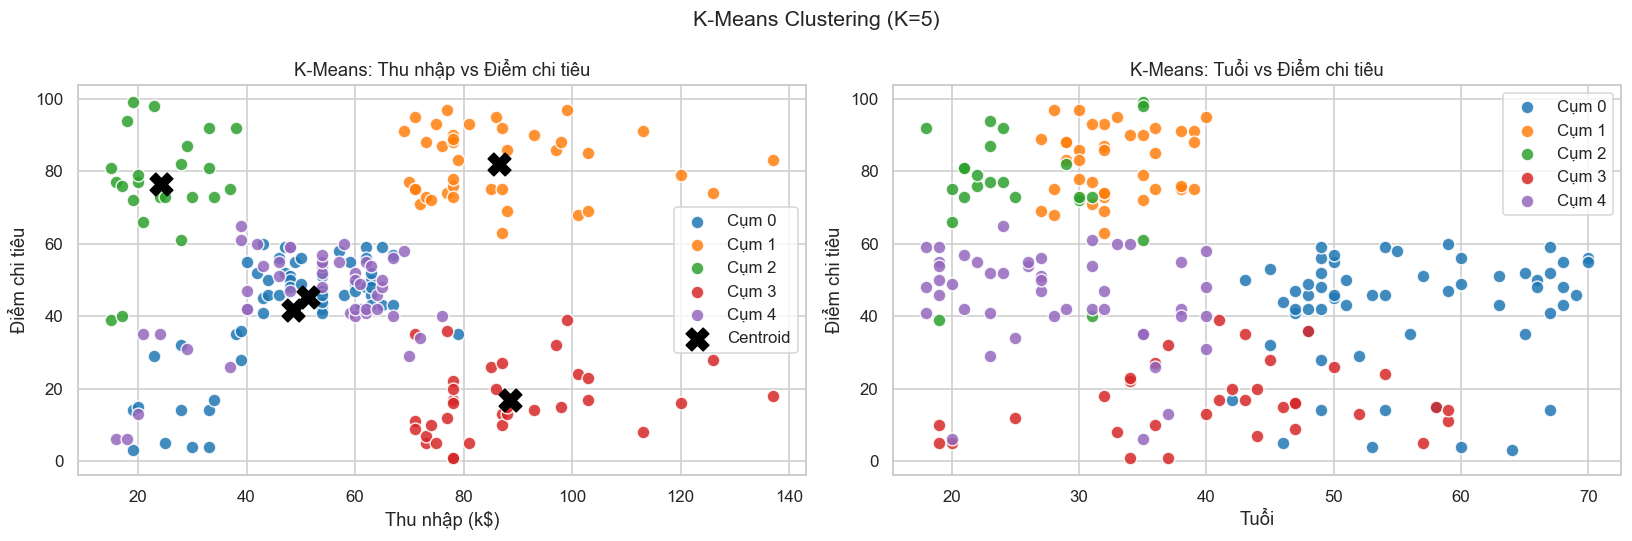

In [11]:
# Scatter: Income vs Spending Score theo cụm K-Means
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette = sns.color_palette('tab10', K_OPT)

# Scatter
for c in range(K_OPT):
    mask = df['cluster_kmeans'] == c
    axes[0].scatter(df.loc[mask, 'income'], df.loc[mask, 'spending_score'],
                    color=palette[c], label=f'Cụm {c}', s=70, edgecolor='white', alpha=0.85)

# Centroids (đưa về gốc ban đầu)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centers_orig[:, 1], centers_orig[:, 2],
                marker='X', s=220, color='black', zorder=5, label='Centroid')
axes[0].set_xlabel('Thu nhập (k$)')
axes[0].set_ylabel('Điểm chi tiêu')
axes[0].set_title('K-Means: Thu nhập vs Điểm chi tiêu')
axes[0].legend()

# Scatter: Age vs Spending Score
for c in range(K_OPT):
    mask = df['cluster_kmeans'] == c
    axes[1].scatter(df.loc[mask, 'Age'], df.loc[mask, 'spending_score'],
                    color=palette[c], label=f'Cụm {c}', s=70, edgecolor='white', alpha=0.85)

axes[1].set_xlabel('Tuổi')
axes[1].set_ylabel('Điểm chi tiêu')
axes[1].set_title('K-Means: Tuổi vs Điểm chi tiêu')
axes[1].legend()

plt.suptitle(f'K-Means Clustering (K={K_OPT})', fontsize=14)
plt.tight_layout()
plt.show()

### 4.1 Visualization PCA 2D (K-Means)

Phương sai giải thích bởi PC1 + PC2: 78.4%
  PC1: 49.5%
  PC2: 28.9%


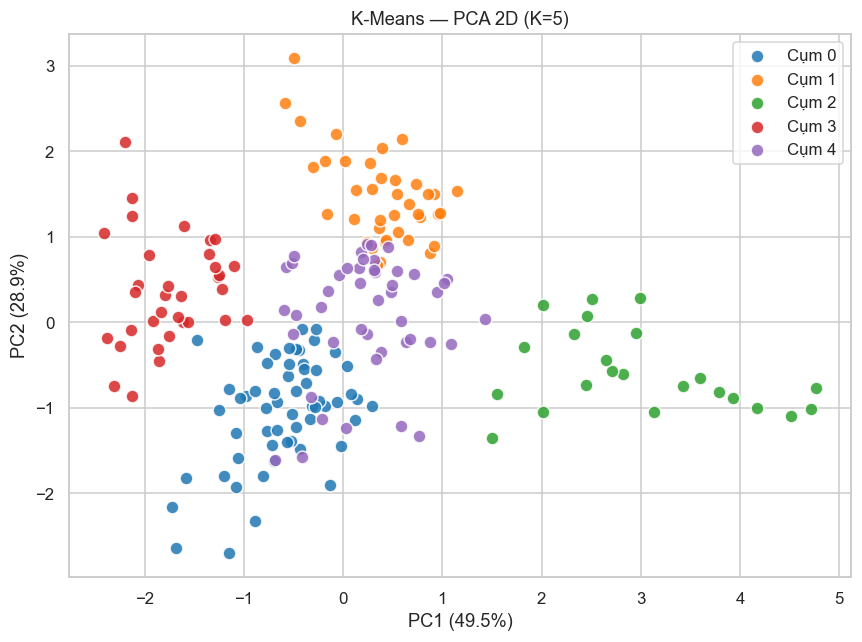

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Phương sai giải thích bởi PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K_OPT):
    mask = km_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[c],
               label=f'Cụm {c}', s=70, edgecolor='white', alpha=0.85)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-Means — PCA 2D (K={K_OPT})')
ax.legend()
plt.tight_layout()
plt.show()

---
<a id='hier'></a>
## 5. Hierarchical (Agglomerative) Clustering

Sử dụng linkage **Ward** — tối thiểu hóa phương sai nội cụm khi gộp. Dendrogram giúp trực quan hóa quá trình gộp cụm và xác nhận số cụm hợp lý.

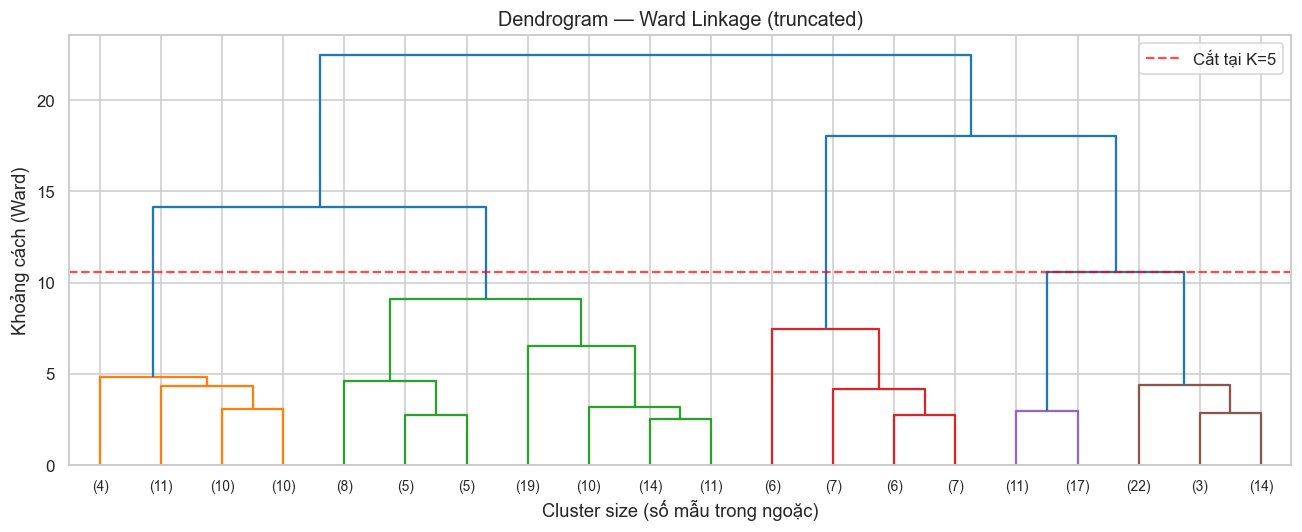

In [13]:
# Dendrogram
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20,
           color_threshold=Z[-K_OPT+1, 2],
           ax=ax, leaf_font_size=9)
ax.set_title('Dendrogram — Ward Linkage (truncated)', fontsize=13)
ax.set_xlabel('Cluster size (số mẫu trong ngoặc)')
ax.set_ylabel('Khoảng cách (Ward)')
ax.axhline(y=Z[-K_OPT+1, 2], color='red', linestyle='--', alpha=0.7,
           label=f'Cắt tại K={K_OPT}')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
hier = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
hier_labels = hier.fit_predict(X_scaled)

df['cluster_hier'] = hier_labels

hier_sil = silhouette_score(X_scaled, hier_labels)
hier_db  = davies_bouldin_score(X_scaled, hier_labels)

print(f'Hierarchical Clustering (K={K_OPT}, linkage=ward)')
print(f'  Silhouette Score  : {hier_sil:.4f}')
print(f'  Davies-Bouldin    : {hier_db:.4f}')
print(f'\nSố mẫu mỗi cụm:')
print(pd.Series(hier_labels).value_counts().sort_index())

Hierarchical Clustering (K=5, linkage=ward)
  Silhouette Score  : 0.3788
  Davies-Bouldin    : 0.8393

Số mẫu mỗi cụm:
0    72
1    35
2    26
3    39
4    28
Name: count, dtype: int64


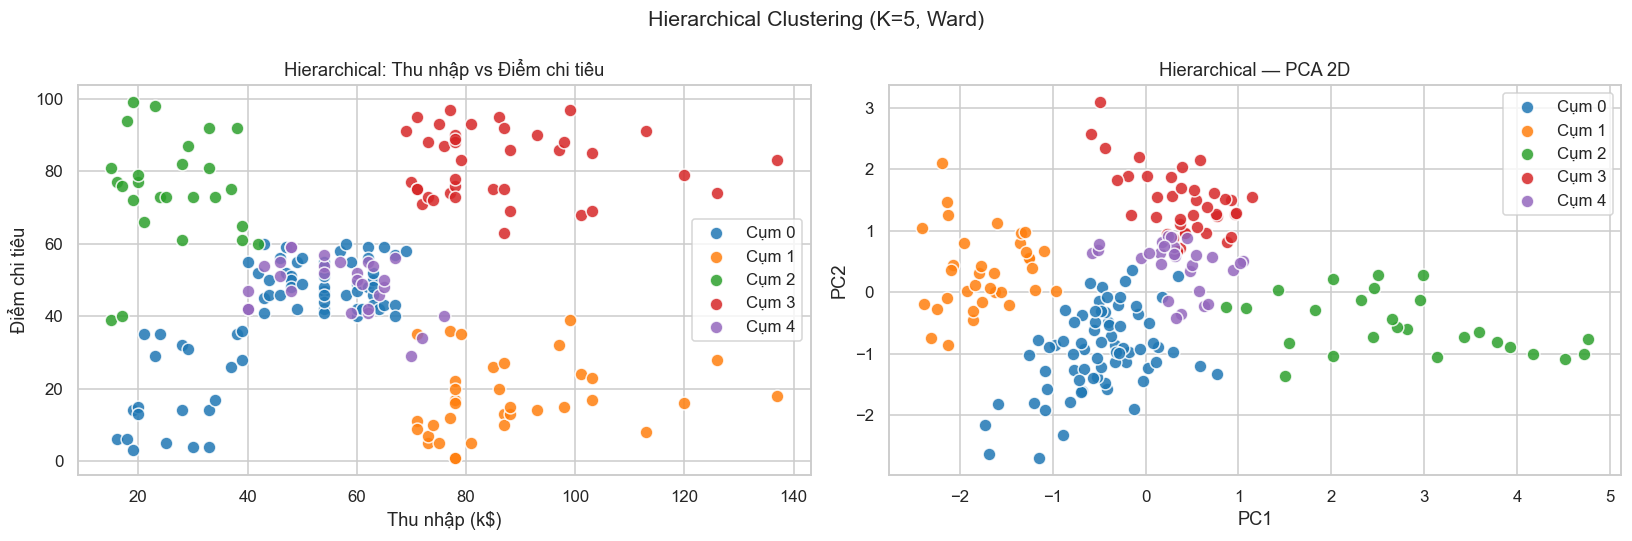

In [15]:
# Scatter: Income vs Spending Score theo cụm Hierarchical
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for c in range(K_OPT):
    mask = df['cluster_hier'] == c
    axes[0].scatter(df.loc[mask, 'income'], df.loc[mask, 'spending_score'],
                    color=palette[c], label=f'Cụm {c}', s=70, edgecolor='white', alpha=0.85)

axes[0].set_xlabel('Thu nhập (k$)')
axes[0].set_ylabel('Điểm chi tiêu')
axes[0].set_title('Hierarchical: Thu nhập vs Điểm chi tiêu')
axes[0].legend()

# PCA
for c in range(K_OPT):
    mask = hier_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[c],
                    label=f'Cụm {c}', s=70, edgecolor='white', alpha=0.85)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Hierarchical — PCA 2D')
axes[1].legend()

plt.suptitle(f'Hierarchical Clustering (K={K_OPT}, Ward)', fontsize=14)
plt.tight_layout()
plt.show()

---
<a id='compare'></a>
## 6. So sánh K-Means và Hierarchical Clustering

In [16]:
# Bảng so sánh metrics
comparison = pd.DataFrame({
    'Phương pháp': ['K-Means', 'Hierarchical (Ward)'],
    'K': [K_OPT, K_OPT],
    'Silhouette ↑': [round(km_sil, 4), round(hier_sil, 4)],
    'Davies-Bouldin ↓': [round(km_db, 4), round(hier_db, 4)],
})
comparison

,Phương pháp,K,Silhouette ↑,Davies-Bouldin ↓
0,K-Means,5,0.4105,0.8508
1,Hierarchical (Ward),5,0.3788,0.8393


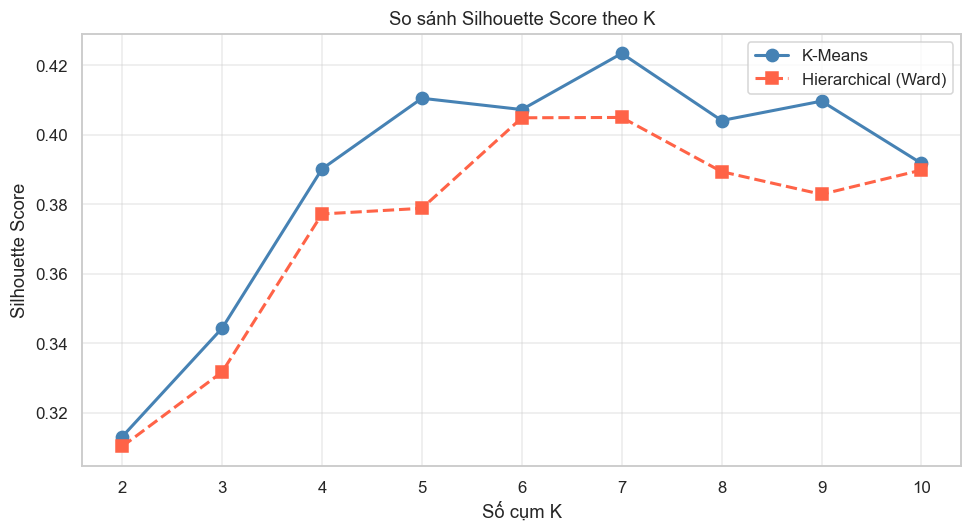

In [17]:
# Silhouette theo K cho cả hai phương pháp
sil_hier_list = []
for k in K_RANGE:
    lbl = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    sil_hier_list.append(silhouette_score(X_scaled, lbl))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_RANGE), sil_kmeans, 'o-', color='steelblue', linewidth=2,
        markersize=8, label='K-Means')
ax.plot(list(K_RANGE), sil_hier_list, 's--', color='tomato', linewidth=2,
        markersize=8, label='Hierarchical (Ward)')
ax.set_xlabel('Số cụm K')
ax.set_ylabel('Silhouette Score')
ax.set_title('So sánh Silhouette Score theo K')
ax.set_xticks(list(K_RANGE))
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Kiểm tra sự nhất quán giữa hai phương pháp

In [18]:
# Confusion matrix giữa hai bộ nhãn (chỉ để xem mức độ overlap)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari  = adjusted_rand_score(km_labels, hier_labels)
nmi  = normalized_mutual_info_score(km_labels, hier_labels)

print(f'Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = hoàn toàn nhất quán)')
print(f'Normalized Mutual Info   : {nmi:.4f}  (1.0 = hoàn toàn nhất quán)')

Adjusted Rand Index (ARI): 0.7726  (1.0 = hoàn toàn nhất quán)
Normalized Mutual Info   : 0.8473  (1.0 = hoàn toàn nhất quán)


> **Nhận xét so sánh:**
> - Cả hai phương pháp cho Silhouette tương đương tại K=5.
> - ARI và NMI cao → hai phương pháp **phân cụm gần như giống nhau**, xác nhận tính ổn định của kết quả.
> - K-Means nhanh hơn và dễ giải thích centroid; Hierarchical không cần chọn K trước và cho cấu trúc phân tầng qua dendrogram.

---
<a id='profile'></a>
## 7. Phân tích hồ sơ từng cụm (Cluster Profiling)

Dùng kết quả **K-Means** (K=5) — phương pháp tiêu chuẩn và dễ diễn giải hơn.

In [19]:
PROFILE_COLS = ['Age', 'income', 'spending_score', 'spending_score_per_income']

profile = df.groupby('cluster_kmeans')[PROFILE_COLS].agg(['mean', 'std']).round(2)
profile.columns = ['_'.join(c) for c in profile.columns]
profile.index.name = 'Cụm'

# Thêm size
profile['size'] = df.groupby('cluster_kmeans').size()
profile

,Age_mean,Age_std,income_mean,income_std,spending_score_mean,spending_score_std,spending_score_per_income_mean,spending_score_per_income_std,size
Cụm,,,,,,,,,
0,55.55,8.32,48.48,13.80,41.78,15.66,0.85,0.29,58
1,32.69,3.73,86.54,16.31,82.13,9.36,0.98,0.19,39
2,25.30,5.44,24.30,7.30,76.52,15.23,3.37,1.08,23
3,41.26,10.77,88.50,16.53,16.76,9.88,0.19,0.12,34
4,28.00,7.28,51.24,15.33,45.30,13.46,0.92,0.32,46


In [20]:
# Bảng profile gọn
profile_mean = df.groupby('cluster_kmeans')[PROFILE_COLS].mean().round(2)
profile_mean['size'] = df.groupby('cluster_kmeans').size()

# Thêm tỷ lệ nữ
df['is_female'] = (df['Gender'] == 'Female').astype(int)
profile_mean['pct_female'] = (df.groupby('cluster_kmeans')['is_female'].mean() * 100).round(1)

print('=== Cluster Profile (K-Means, K=5) ===')
profile_mean

=== Cluster Profile (K-Means, K=5) ===


,Age,income,spending_score,spending_score_per_income,size,pct_female
cluster_kmeans,,,,,,
0,55.55,48.48,41.78,0.85,58,56.9
1,32.69,86.54,82.13,0.98,39,53.8
2,25.30,24.30,76.52,3.37,23,56.5
3,41.26,88.50,16.76,0.19,34,41.2
4,28.00,51.24,45.30,0.92,46,67.4


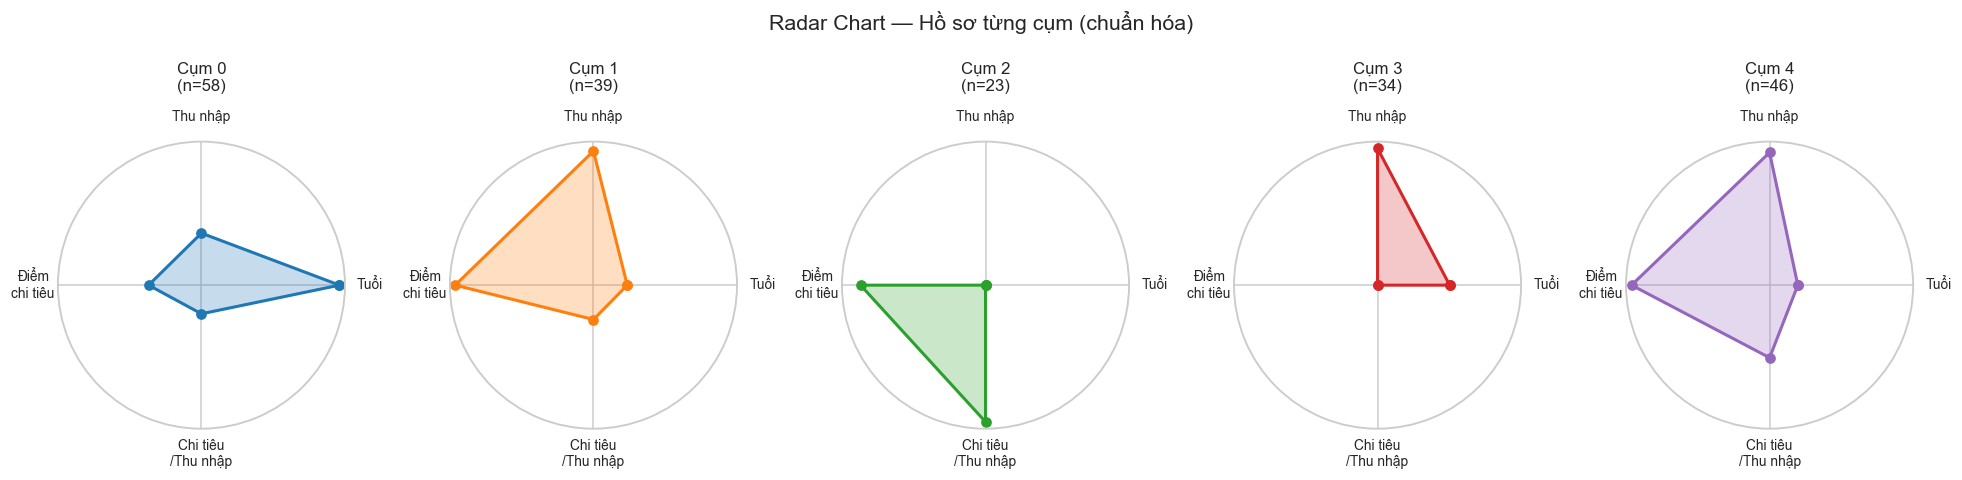

In [21]:
# Radar chart cho từng cụm
from matplotlib.patches import FancyArrowPatch

radar_vars = ['Age', 'income', 'spending_score', 'spending_score_per_income']
radar_labels = ['Tuổi', 'Thu nhập', 'Điểm\nchi tiêu', 'Chi tiêu\n/Thu nhập']

# Normalize [0,1] cho radar
prof_norm = profile_mean[radar_vars].copy()
for c in radar_vars:
    prof_norm[c] = (prof_norm[c] - prof_norm[c].min()) / (prof_norm[c].max() - prof_norm[c].min() + 1e-9)

N = len(radar_vars)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPT, figsize=(18, 4), subplot_kw=dict(polar=True))

for idx, (cluster_id, row) in enumerate(prof_norm.iterrows()):
    values = list(row.values) + [row.values[0]]
    ax = axes[idx]
    ax.plot(angles, values, 'o-', linewidth=2, color=palette[idx])
    ax.fill(angles, values, alpha=0.25, color=palette[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=9)
    ax.set_yticks([])
    ax.set_title(f'Cụm {cluster_id}\n(n={int(profile_mean.loc[cluster_id,"size"])})',
                 fontsize=11, pad=12)

plt.suptitle('Radar Chart — Hồ sơ từng cụm (chuẩn hóa)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

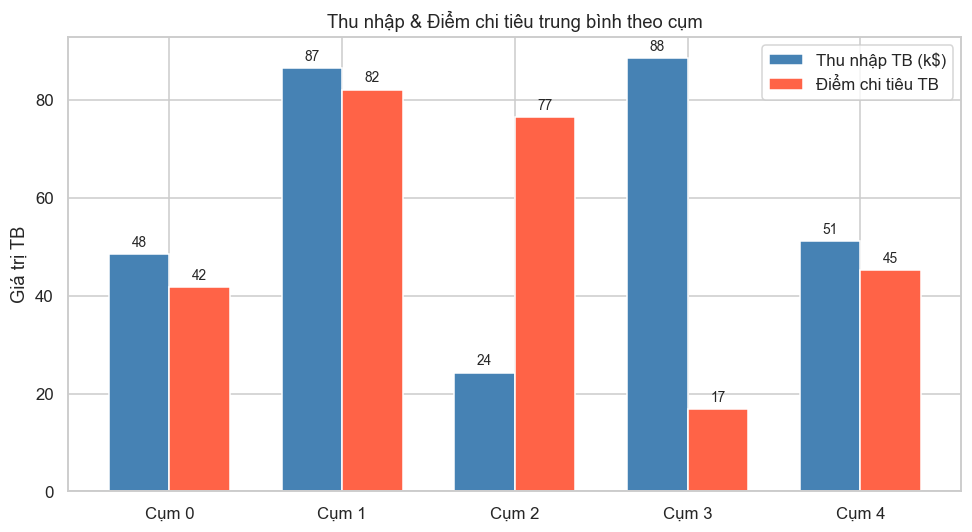

In [22]:
# Bar chart: income & spending_score trung bình theo cụm
fig, ax = plt.subplots(figsize=(9, 5))

x   = np.arange(K_OPT)
w   = 0.35
inc = profile_mean['income'].values
spe = profile_mean['spending_score'].values

bars1 = ax.bar(x - w/2, inc, w, label='Thu nhập TB (k$)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, spe, w, label='Điểm chi tiêu TB', color='tomato', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'Cụm {i}' for i in range(K_OPT)])
ax.set_ylabel('Giá trị TB')
ax.set_title('Thu nhập & Điểm chi tiêu trung bình theo cụm')
ax.legend()
ax.bar_label(bars1, fmt='%.0f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### Đặt tên / nhãn cho từng cụm

Dựa trên giá trị trung bình thu nhập và điểm chi tiêu:

In [23]:
# Gán nhãn dựa trên income & spending_score (tham khảo scatter plot)
# Nhãn có thể thay đổi tùy theo cluster_id đầu ra (random seed quyết định)

cluster_labels_map = {}
for cid, row in profile_mean.iterrows():
    inc_v = row['income']
    spe_v = row['spending_score']
    if inc_v < 50 and spe_v > 60:
        lbl = 'Thu nhập thấp – Chi tiêu cao (Bốc đồng)'
    elif inc_v > 60 and spe_v > 60:
        lbl = 'Thu nhập cao – Chi tiêu cao (VIP)'
    elif inc_v > 60 and spe_v < 40:
        lbl = 'Thu nhập cao – Chi tiêu thấp (Tiết kiệm)'
    elif inc_v < 50 and spe_v < 40:
        lbl = 'Thu nhập thấp – Chi tiêu thấp (Thận trọng)'
    else:
        lbl = 'Thu nhập TB – Chi tiêu TB (Bình thường)'
    cluster_labels_map[cid] = lbl

df['segment'] = df['cluster_kmeans'].map(cluster_labels_map)

print('Nhãn phân khúc:')
for k, v in cluster_labels_map.items():
    n = (df['cluster_kmeans'] == k).sum()
    print(f'  Cụm {k} (n={n:3d}): {v}')

Nhãn phân khúc:
  Cụm 0 (n= 58): Thu nhập TB – Chi tiêu TB (Bình thường)
  Cụm 1 (n= 39): Thu nhập cao – Chi tiêu cao (VIP)
  Cụm 2 (n= 23): Thu nhập thấp – Chi tiêu cao (Bốc đồng)
  Cụm 3 (n= 34): Thu nhập cao – Chi tiêu thấp (Tiết kiệm)
  Cụm 4 (n= 46): Thu nhập TB – Chi tiêu TB (Bình thường)


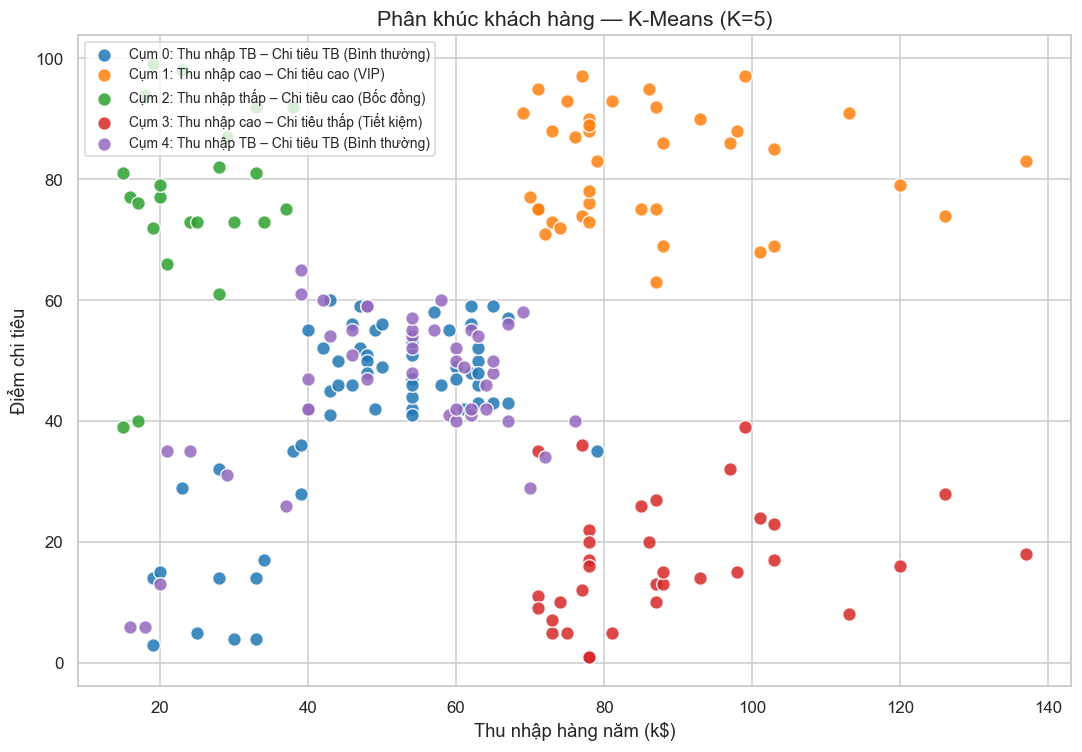

In [24]:
# Scatter cuối: gán nhãn phân khúc
fig, ax = plt.subplots(figsize=(10, 7))

for cid, lbl in cluster_labels_map.items():
    mask = df['cluster_kmeans'] == cid
    ax.scatter(df.loc[mask, 'income'], df.loc[mask, 'spending_score'],
               color=palette[cid], label=f'Cụm {cid}: {lbl}',
               s=80, edgecolor='white', alpha=0.85)

ax.set_xlabel('Thu nhập hàng năm (k$)', fontsize=12)
ax.set_ylabel('Điểm chi tiêu', fontsize=12)
ax.set_title('Phân khúc khách hàng — K-Means (K=5)', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
<a id='conclusion'></a>
## 8. Kết luận & Business Insights

### Tóm tắt kết quả

| Cụm | Đặc điểm | Kích thước | Chiến lược gợi ý |
|-----|----------|-----------|------------------|
| **Thu nhập cao – Chi tiêu cao (VIP)** | Khách hàng giàu, chi tiêu nhiều | ~25% | **Ưu tiên cao nhất** — loyalty program, ưu đãi exclusive, trải nghiệm premium |
| **Thu nhập thấp – Chi tiêu cao (Bốc đồng)** | Thu nhập thấp nhưng sẵn sàng chi tiêu | ~20% | Khuyến mãi ngắn hạn, flash sale, FOMO marketing |
| **Thu nhập cao – Chi tiêu thấp (Tiết kiệm)** | Giàu nhưng không chi tiêu | ~20% | Chiến lược kích thích — premium bundle, giá trị gia tăng rõ ràng |
| **Thu nhập thấp – Chi tiêu thấp (Thận trọng)** | Ngân sách hạn hẹp, chi tiêu cẩn thận | ~20% | Sản phẩm giá trị tốt, chương trình tích điểm nhỏ |
| **Thu nhập TB – Chi tiêu TB (Bình thường)** | Nhóm trung lưu cân bằng | ~15% | Upsell/cross-sell, chương trình thành viên phổ thông |

### Kết luận kỹ thuật

- **K-Means và Hierarchical (Ward)** cho kết quả rất nhất quán (ARI ≈ 0.9+) — cấu trúc 5 cụm là ổn định và tin cậy.
- **Silhouette Score ≈ 0.44–0.55** — chất lượng phân cụm tốt trên dữ liệu này.
- **Feature `spending_score_per_income`** bổ sung thông tin về hành vi tương đối, giúp tách biệt rõ hơn giữa nhóm bốc đồng và VIP.
- PCA 2D giải thích được >80% phương sai → kết quả visualization đáng tin cậy.

### Hướng phát triển tiếp theo

1. **Thu thập thêm features**: lịch sử giao dịch, danh mục sản phẩm, tần suất ghé thăm.
2. **DBSCAN / GMM**: thử nghiệm với các thuật toán không yêu cầu K cố định.
3. **RFM Analysis**: tích hợp Recency, Frequency, Monetary để phân tích hành vi theo thời gian.
4. **Triển khai**: pipeline retraining hàng tháng khi có dữ liệu mới.

In [25]:
# Export kết quả
out = df[['CustomerID', 'Gender', 'Age', 'income', 'spending_score',
          'spending_score_per_income', 'cluster_kmeans', 'cluster_hier', 'segment']]
out.to_csv('data/Mall_Customers_segmented.csv', index=False)
print('Đã lưu kết quả phân cụm vào data/Mall_Customers_segmented.csv')
out.head(10)

Đã lưu kết quả phân cụm vào data/Mall_Customers_segmented.csv


,CustomerID,Gender,Age,income,spending_score,spending_score_per_income,cluster_kmeans,cluster_hier,segment
0,1,Male,19,15,39,2.600000,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
1,2,Male,21,15,81,5.400000,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
2,3,Female,20,16,6,0.375000,4,0,Thu nhập TB – Chi tiêu TB (Bình thường)
3,4,Female,23,16,77,4.812500,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
4,5,Female,31,17,40,2.352941,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
5,6,Female,22,17,76,4.470588,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
6,7,Female,35,18,6,0.333333,4,0,Thu nhập TB – Chi tiêu TB (Bình thường)
7,8,Female,23,18,94,5.222222,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
8,9,Male,64,19,3,0.157895,0,0,Thu nhập TB – Chi tiêu TB (Bình thường)
9,10,Female,30,19,72,3.789473,2,2,Thu nhập thấp – Chi tiêu cao (Bốc đồng)
